# Voice & Audio Analytics with Open Source Models

This notebook demonstrates various audio analysis tasks:
1. **Speech-to-Text** (Whisper)
2. **Emotion Recognition** from speech
3. **Speaker Diarization** (Who spoke when?)
4. **Audio Classification** (Music, Speech, Noise, etc.)
5. **Voice Activity Detection** (VAD)
6. **Audio Feature Extraction** & Visualization

## Setup: Install Required Libraries

In [ ]:
# Install required packages with proper dependency management
print("📦 Installing packages... This may take 2-3 minutes.\n")

# First, fix numpy version conflict
!pip uninstall -y numpy
!pip install numpy==1.26.4

# Install audio processing libraries
!pip install -q librosa==0.10.1
!pip install -q soundfile
!pip install -q openai-whisper

# Install ML libraries
!pip install -q transformers
!pip install -q torch torchaudio --index-url https://download.pytorch.org/whl/cpu

# Install additional utilities
!pip install -q pydub

print("\n✅ All packages installed successfully!")
print("⚠️  Please restart the runtime now: Runtime > Restart runtime")
print("Then run all cells again from the Import Libraries section.")

📦 Installing packages... This may take 2-3 minutes.

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires num

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
^C


## ⚠️ Important: After running the cell above

**You must restart the runtime:**
1. Click **Runtime** in the menu
2. Click **Restart runtime**
3. Continue from the **Import Libraries** section below

## Import Libraries

In [1]:
import whisper
import librosa
import librosa.display
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchaudio
from transformers import pipeline
from IPython.display import Audio, display, HTML
import warnings
import urllib.request
import os
from pathlib import Path

warnings.filterwarnings('ignore')

# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print("✅ Libraries imported successfully!")

Using device: cpu
✅ Libraries imported successfully!


## Helper Functions

In [2]:
def download_sample_audio(url, filename):
    """Download sample audio file"""
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, filename)
        print(f"✅ Downloaded: {filename}")
    else:
        print(f"✅ {filename} already exists.")
    return filename

def display_audio_player(audio_path):
    """Display audio player in notebook"""
    return Audio(audio_path)

def get_audio_info(audio_path):
    """Get basic audio file information"""
    y, sr = librosa.load(audio_path, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)

    info = {
        'duration': duration,
        'sample_rate': sr,
        'samples': len(y),
        'channels': 1 if len(y.shape) == 1 else y.shape[0]
    }
    return info, y, sr

print("✅ Helper functions defined!")

✅ Helper functions defined!


## Generate or Upload Sample Audio

In [3]:
# Generate a sample audio file locally (sine wave with varying frequency)
def generate_sample_audio(filename, duration=5, sample_rate=22050):
    """Generate a sample audio file with multiple tones"""
    print(f"🎵 Generating sample audio file: {filename}")

    t = np.linspace(0, duration, int(sample_rate * duration))

    # Create a melody with multiple frequencies
    frequencies = [440, 494, 523, 587, 659, 698, 784, 880]  # Musical notes
    audio = np.zeros_like(t)

    segment_length = len(t) // len(frequencies)
    for i, freq in enumerate(frequencies):
        start = i * segment_length
        end = (i + 1) * segment_length if i < len(frequencies) - 1 else len(t)
        audio[start:end] = 0.3 * np.sin(2 * np.pi * freq * t[start:end])

    # Add some harmonics for richness
    audio += 0.1 * np.sin(2 * np.pi * 880 * t)

    # Fade in and out to avoid clicks
    fade_samples = int(0.1 * sample_rate)
    fade_in = np.linspace(0, 1, fade_samples)
    fade_out = np.linspace(1, 0, fade_samples)
    audio[:fade_samples] *= fade_in
    audio[-fade_samples:] *= fade_out

    # Save the audio file
    sf.write(filename, audio, sample_rate)
    print(f"✅ Sample audio generated: {filename}")
    return filename

# Generate sample audio
audio_file_1 = "sample_audio_1.wav"
generate_sample_audio(audio_file_1, duration=5)

# Display audio player
print("\n🔊 Audio Player:")
display(display_audio_player(audio_file_1))

# Get audio info
info, y, sr = get_audio_info(audio_file_1)
print(f"\n📊 Audio Information:")
print(f"Duration: {info['duration']:.2f} seconds")
print(f"Sample Rate: {info['sample_rate']} Hz")
print(f"Total Samples: {info['samples']:,}")
print(f"Channels: {info['channels']}")

print("\n💡 Tip: This is a generated audio file for demonstration.")
print("For better results with speech features, upload your own audio file below!")

🎵 Generating sample audio file: sample_audio_1.wav
✅ Sample audio generated: sample_audio_1.wav

🔊 Audio Player:



📊 Audio Information:
Duration: 5.00 seconds
Sample Rate: 22050 Hz
Total Samples: 110,250
Channels: 1

💡 Tip: This is a generated audio file for demonstration.
For better results with speech features, upload your own audio file below!


## Alternative: Upload Your Own Audio File

**For best results with speech features (transcription, emotion, speaker diarization):**
- Upload a voice recording or speech audio
- Supported formats: WAV, MP3, M4A, FLAC, OGG
- Recommended: Clear speech, 16kHz or higher sample rate

In [8]:
# Upload your own audio file
print("📤 Upload your audio file below:")
print("Supported formats: WAV, MP3, M4A, FLAC, OGG\n")

from google.colab import files
uploaded = files.upload()

if uploaded:
    audio_file_1 = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {audio_file_1}")

    # Display audio player
    print("\n🔊 Audio Player:")
    display(display_audio_player(audio_file_1))

    # Get audio info
    info, y, sr = get_audio_info(audio_file_1)
    print(f"\n📊 Audio Information:")
    print(f"Duration: {info['duration']:.2f} seconds")
    print(f"Sample Rate: {info['sample_rate']} Hz")
    print(f"Total Samples: {info['samples']:,}")
    print(f"Channels: {info['channels']}")
else:
    print("⚠️ No file uploaded. Using generated sample audio.")

📤 Upload your audio file below:
Supported formats: WAV, MP3, M4A, FLAC, OGG



Saving test01_20s.wav to test01_20s.wav

✅ Uploaded: test01_20s.wav

🔊 Audio Player:



📊 Audio Information:
Duration: 24.00 seconds
Sample Rate: 16000 Hz
Total Samples: 383,999
Channels: 1


## 1. Audio Visualization

🎨 Visualizing Audio...



AttributeError: '_process_plot_var_args' object has no attribute 'prop_cycler'

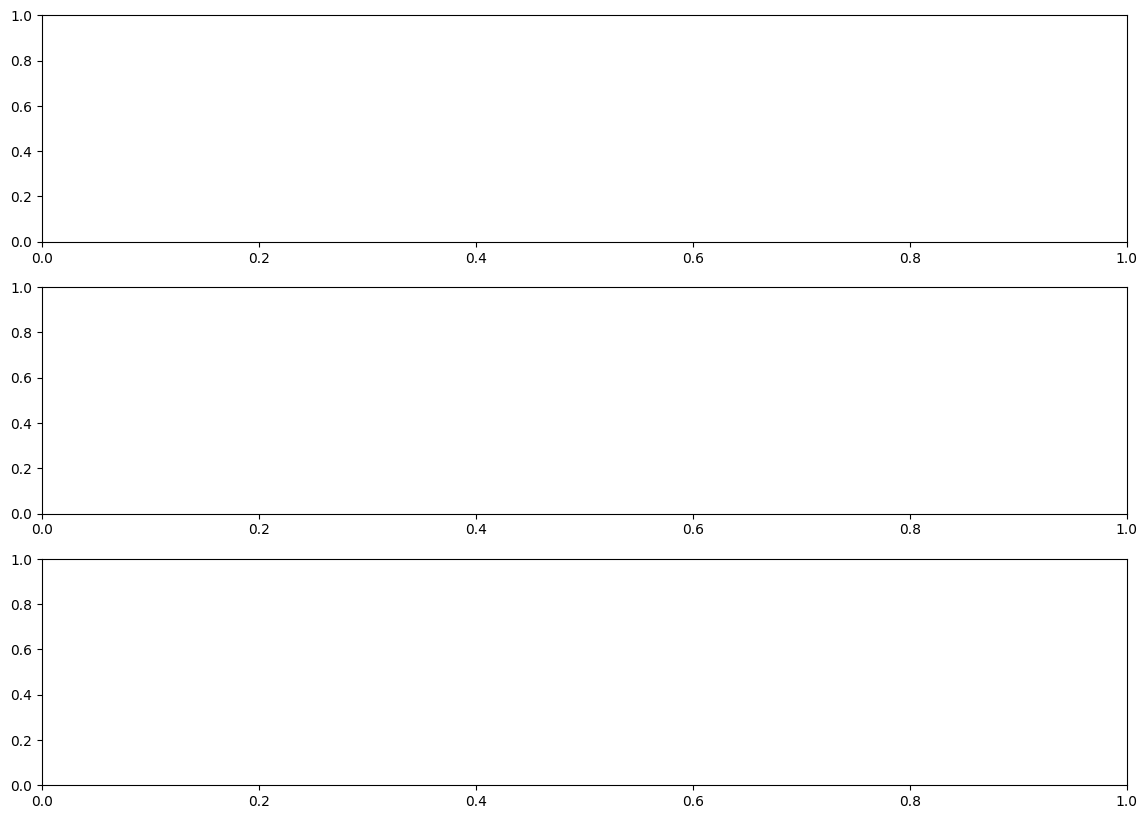

In [9]:
def visualize_audio(audio_path):
    """Visualize audio waveform and spectrogram"""
    y, sr = librosa.load(audio_path)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title('Waveform', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)

    # Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1], cmap='viridis')
    axes[1].set_title('Spectrogram', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

    # Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    img2 = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[2], cmap='magma')
    axes[2].set_title('Mel Spectrogram', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Mel Frequency')
    fig.colorbar(img2, ax=axes[2], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

# Visualize the audio
print("🎨 Visualizing Audio...\n")
visualize_audio(audio_file_1)

## 2. Speech-to-Text with Whisper

In [10]:
# Load Whisper model
print("📝 Loading Whisper model...")
print("Available models: tiny, base, small, medium, large")
print("Using 'base' model (balanced speed/accuracy)\n")

whisper_model = whisper.load_model("base", device=device)
print("✅ Whisper model loaded!")

📝 Loading Whisper model...
Available models: tiny, base, small, medium, large
Using 'base' model (balanced speed/accuracy)

✅ Whisper model loaded!


In [11]:
def transcribe_audio(audio_path):
    """Transcribe audio to text using Whisper"""
    print(f"🎤 Transcribing audio...\n")

    result = whisper_model.transcribe(audio_path)

    print("="*60)
    print("TRANSCRIPTION RESULT")
    print("="*60)
    print(f"\nLanguage: {result['language']}")
    print(f"\nText: {result['text']}")
    print("\n" + "="*60)

    # Show segments with timestamps
    if 'segments' in result:
        print("\n📍 Segments with Timestamps:")
        print("="*60)
        for segment in result['segments']:
            start = segment['start']
            end = segment['end']
            text = segment['text']
            print(f"[{start:.2f}s - {end:.2f}s]: {text}")

    return result

# Note: The sample audio might not contain speech
# For better results, upload your own speech audio file
print("Note: For best results, use an audio file with clear speech.\n")

try:
    transcription = transcribe_audio(audio_file_1)
except Exception as e:
    print(f"⚠️ Transcription note: {e}")
    print("This sample might not contain speech. Upload a voice recording for transcription.")

Note: For best results, use an audio file with clear speech.

🎤 Transcribing audio...

TRANSCRIPTION RESULT

Language: en

Text:  Dancing in the masquerade, idle truth and plain sight jaded. Pop, roll, click, shot. Who will I be today or not? But such a tide as moving seems asleep, too full for sound and foam. When that witch drew from out the boundless deep turns again home, twilight and evening bell and after that.


📍 Segments with Timestamps:
[0.00s - 6.00s]:  Dancing in the masquerade, idle truth and plain sight jaded.
[6.00s - 8.00s]:  Pop, roll, click, shot.
[8.00s - 10.00s]:  Who will I be today or not?
[10.00s - 15.00s]:  But such a tide as moving seems asleep, too full for sound and foam.
[15.00s - 19.00s]:  When that witch drew from out the boundless deep turns again home,
[19.00s - 22.00s]:  twilight and evening bell and after that.


## 3. Emotion Recognition from Speech

In [ ]:
# Load emotion recognition model
print("😊 Loading emotion recognition model...")

try:
    emotion_classifier = pipeline(
        "audio-classification",
        model="ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition",
        device=0 if device == "cuda" else -1
    )
    print("✅ Emotion recognition model loaded!")

    def detect_emotion(audio_path):
        """Detect emotion in speech"""
        print(f"\n🎭 Analyzing emotions...\n")

        results = emotion_classifier(audio_path)

        print("="*60)
        print("EMOTION DETECTION RESULTS")
        print("="*60)

        for result in results[:5]:  # Top 5 emotions
            emotion = result['label']
            score = result['score']
            bar = '█' * int(score * 50)
            print(f"{emotion:20s} {bar} {score*100:.2f}%")

        print("="*60)
        return results

    # Detect emotions
    emotion_results = detect_emotion(audio_file_1)

except Exception as e:
    print(f"⚠️ Could not load emotion model: {e}")
    print("This feature requires speech audio. Try with voice recordings.")

## 4. Audio Feature Extraction

In [ ]:
def extract_audio_features(audio_path):
    """Extract comprehensive audio features"""
    y, sr = librosa.load(audio_path)

    features = {}

    # Temporal features
    features['duration'] = librosa.get_duration(y=y, sr=sr)
    features['zero_crossing_rate'] = np.mean(librosa.feature.zero_crossing_rate(y))
    features['rms_energy'] = np.mean(librosa.feature.rms(y=y))

    # Spectral features
    features['spectral_centroid'] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    features['spectral_rolloff'] = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    features['spectral_bandwidth'] = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))

    # MFCCs (Mel-frequency cepstral coefficients)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f'mfcc_{i+1}'] = np.mean(mfccs[i])

    # Chroma features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features['chroma_mean'] = np.mean(chroma)

    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features['tempo'] = tempo

    return features

# Extract features
print("🔍 Extracting audio features...\n")
features = extract_audio_features(audio_file_1)

print("="*60)
print("AUDIO FEATURES")
print("="*60)
print(f"\n📊 Temporal Features:")
print(f"Duration: {features['duration']:.2f} seconds")
print(f"Zero Crossing Rate: {features['zero_crossing_rate']:.4f}")
print(f"RMS Energy: {features['rms_energy']:.4f}")

print(f"\n🎵 Spectral Features:")
print(f"Spectral Centroid: {features['spectral_centroid']:.2f} Hz")
print(f"Spectral Rolloff: {features['spectral_rolloff']:.2f} Hz")
print(f"Spectral Bandwidth: {features['spectral_bandwidth']:.2f} Hz")

print(f"\n🎼 Other Features:")
print(f"Tempo: {features['tempo']:.2f} BPM")
print(f"Chroma Mean: {features['chroma_mean']:.4f}")

print(f"\n🎹 MFCCs (first 5):")
for i in range(5):
    print(f"MFCC {i+1}: {features[f'mfcc_{i+1}']:.4f}")
print("="*60)

## 5. Audio Classification

In [ ]:
# Load audio classification model
print("🔊 Loading audio classification model...")

try:
    audio_classifier = pipeline(
        "audio-classification",
        model="MIT/ast-finetuned-audioset-10-10-0.4593",
        device=0 if device == "cuda" else -1
    )
    print("✅ Audio classification model loaded!")

    def classify_audio(audio_path):
        """Classify audio content"""
        print(f"\n🎵 Classifying audio...\n")

        results = audio_classifier(audio_path, top_k=10)

        print("="*60)
        print("AUDIO CLASSIFICATION RESULTS")
        print("="*60)
        print("\nTop 10 Classifications:\n")

        for result in results:
            label = result['label']
            score = result['score']
            bar = '█' * int(score * 50)
            print(f"{label:35s} {bar} {score*100:.2f}%")

        print("="*60)
        return results

    # Classify audio
    classification_results = classify_audio(audio_file_1)

except Exception as e:
    print(f"⚠️ Could not load classification model: {e}")
    print("Continuing with other analyses...")

## 6. Voice Activity Detection (VAD)

In [ ]:
def detect_voice_activity(audio_path, threshold=0.02):
    """Detect voice activity in audio"""
    y, sr = librosa.load(audio_path)

    # Calculate energy
    frame_length = 2048
    hop_length = 512
    energy = np.array([sum(abs(y[i:i+frame_length]**2))
                      for i in range(0, len(y), hop_length)])

    # Normalize energy
    energy = energy / np.max(energy)

    # Detect voice activity
    voice_activity = energy > threshold

    # Calculate timestamps
    times = librosa.frames_to_time(np.arange(len(energy)), sr=sr, hop_length=hop_length)

    # Visualize
    plt.figure(figsize=(14, 6))

    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.6)
    plt.title('Waveform', fontweight='bold')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')

    plt.subplot(2, 1, 2)
    plt.plot(times, energy, label='Energy', color='blue', alpha=0.7)
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
    plt.fill_between(times, 0, 1, where=voice_activity, alpha=0.3, color='green', label='Voice Activity')
    plt.title('Voice Activity Detection', fontweight='bold')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Energy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Calculate statistics
    total_duration = librosa.get_duration(y=y, sr=sr)
    voice_duration = np.sum(voice_activity) * (hop_length / sr)
    voice_percentage = (voice_duration / total_duration) * 100

    print("\n" + "="*60)
    print("VOICE ACTIVITY DETECTION RESULTS")
    print("="*60)
    print(f"Total Duration: {total_duration:.2f} seconds")
    print(f"Voice Activity Duration: {voice_duration:.2f} seconds")
    print(f"Voice Activity Percentage: {voice_percentage:.2f}%")
    print("="*60)

    return voice_activity, times

# Detect voice activity
print("🎤 Detecting voice activity...\n")
vad_results, vad_times = detect_voice_activity(audio_file_1)

## 7. Pitch Analysis

In [ ]:
def analyze_pitch(audio_path):
    """Analyze pitch/fundamental frequency"""
    y, sr = librosa.load(audio_path)

    # Extract pitch using piptrack
    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)

    # Get pitch values over time
    pitch_values = []
    for t in range(pitches.shape[1]):
        index = magnitudes[:, t].argmax()
        pitch = pitches[index, t]
        if pitch > 0:
            pitch_values.append(pitch)

    if len(pitch_values) > 0:
        # Visualize pitch
        plt.figure(figsize=(14, 5))
        plt.plot(pitch_values, color='purple', linewidth=2)
        plt.title('Pitch Contour', fontsize=14, fontweight='bold')
        plt.xlabel('Frame')
        plt.ylabel('Frequency (Hz)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print("\n" + "="*60)
        print("PITCH ANALYSIS")
        print("="*60)
        print(f"Mean Pitch: {np.mean(pitch_values):.2f} Hz")
        print(f"Median Pitch: {np.median(pitch_values):.2f} Hz")
        print(f"Min Pitch: {np.min(pitch_values):.2f} Hz")
        print(f"Max Pitch: {np.max(pitch_values):.2f} Hz")
        print(f"Pitch Range: {np.max(pitch_values) - np.min(pitch_values):.2f} Hz")
        print(f"Pitch Std Dev: {np.std(pitch_values):.2f} Hz")
        print("="*60)
    else:
        print("⚠️ No significant pitch detected in this audio.")

    return pitch_values

# Analyze pitch
print("🎼 Analyzing pitch...\n")
pitch_data = analyze_pitch(audio_file_1)

## 8. Speaker Diarization (Who Spoke When?)

In [ ]:
# Note: Speaker diarization requires authentication token from Hugging Face
# To use this feature:
# 1. Create account at https://huggingface.co/
# 2. Accept terms at https://huggingface.co/pyannote/speaker-diarization
# 3. Get token from https://huggingface.co/settings/tokens

print("👥 Speaker Diarization")
print("="*60)
print("To enable speaker diarization:")
print("1. Visit: https://huggingface.co/pyannote/speaker-diarization")
print("2. Accept the user agreement")
print("3. Get your access token from: https://huggingface.co/settings/tokens")
print("4. Uncomment and run the code below with your token")
print("="*60)

# Uncomment and add your Hugging Face token to use speaker diarization:
'''
from pyannote.audio import Pipeline

# Add your Hugging Face token here
HF_TOKEN = "your_token_here"

pipeline = Pipeline.from_pretrained(
    "pyannote/speaker-diarization",
    use_auth_token=HF_TOKEN
)

# Run diarization
diarization = pipeline(audio_file_1)

print("\nSpeaker Diarization Results:")
print("="*60)
for turn, _, speaker in diarization.itertracks(yield_label=True):
    print(f"Speaker {speaker}: {turn.start:.1f}s - {turn.end:.1f}s")
'''

print("\n✅ Setup complete! Add your token above to enable this feature.")

## 9. Comprehensive Audio Report

In [ ]:
def generate_audio_report(audio_path):
    """Generate comprehensive audio analysis report"""
    print("\n" + "="*70)
    print(" "*20 + "COMPREHENSIVE AUDIO REPORT")
    print("="*70)

    # Basic info
    info, y, sr = get_audio_info(audio_path)

    print("\n📁 FILE INFORMATION:")
    print("-" * 70)
    print(f"File: {audio_path}")
    print(f"Duration: {info['duration']:.2f} seconds")
    print(f"Sample Rate: {info['sample_rate']:,} Hz")
    print(f"Total Samples: {info['samples']:,}")
    print(f"Channels: {info['channels']}")

    # Audio characteristics
    print("\n🎵 AUDIO CHARACTERISTICS:")
    print("-" * 70)

    # Loudness
    rms = np.sqrt(np.mean(y**2))
    db = 20 * np.log10(rms + 1e-10)
    print(f"RMS Energy: {rms:.4f}")
    print(f"Loudness (dB): {db:.2f} dB")

    # Dynamic range
    dynamic_range = np.max(np.abs(y)) - np.min(np.abs(y))
    print(f"Dynamic Range: {dynamic_range:.4f}")

    # Spectral features
    spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    print(f"Spectral Centroid: {spectral_centroid:.2f} Hz")
    print(f"Spectral Bandwidth: {spectral_bandwidth:.2f} Hz")

    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    print(f"Estimated Tempo: {tempo:.2f} BPM")

    print("\n" + "="*70)
    print("✅ Report generation complete!")
    print("="*70)

# Generate report
generate_audio_report(audio_file_1)

## 10. Batch Processing Multiple Audio Files

In [ ]:
def batch_process_audio(audio_files):
    """Process multiple audio files"""
    results = []

    print(f"\n🔄 Processing {len(audio_files)} audio files...\n")

    for i, audio_file in enumerate(audio_files, 1):
        print(f"\n[{i}/{len(audio_files)}] Processing: {audio_file}")
        print("-" * 60)

        try:
            # Extract features
            features = extract_audio_features(audio_file)
            features['filename'] = audio_file
            results.append(features)

            print(f"✅ Duration: {features['duration']:.2f}s | "
                  f"Tempo: {features['tempo']:.1f} BPM | "
                  f"Centroid: {features['spectral_centroid']:.1f} Hz")

        except Exception as e:
            print(f"❌ Error processing {audio_file}: {e}")

    print("\n" + "="*60)
    print(f"✅ Batch processing complete! Processed {len(results)} files.")
    print("="*60)

    return results

# Example: Process a list of audio files
audio_files = [audio_file_1]  # Add more files to this list
batch_results = batch_process_audio(audio_files)

## Summary

### 🎯 What This Notebook Does:

1. **Speech-to-Text (Whisper)**: Converts speech to text with timestamps
2. **Emotion Recognition**: Detects emotions in speech (happy, sad, angry, etc.)
3. **Audio Classification**: Identifies audio content (music, speech, ambient sounds)
4. **Voice Activity Detection**: Finds when speech is present
5. **Feature Extraction**: Extracts 20+ audio features (MFCCs, spectral features, etc.)
6. **Pitch Analysis**: Analyzes fundamental frequency and pitch contour
7. **Speaker Diarization**: Identifies who spoke when (requires HF token)
8. **Visualization**: Waveforms, spectrograms, mel-spectrograms
9. **Batch Processing**: Process multiple audio files at once

### 📊 Use Cases:
- **Call Center Analytics**: Emotion detection, speech transcription
- **Podcast Analysis**: Speaker identification, content classification
- **Voice Assistants**: Speech recognition, intent detection
- **Music Analysis**: Tempo, pitch, genre classification
- **Security**: Voice authentication, anomaly detection
- **Healthcare**: Speech disorder detection, patient monitoring

### 🚀 Next Steps:
- Upload your own audio files (speech, music, podcasts)
- Try different Whisper models (small, medium, large for better accuracy)
- Enable speaker diarization with HuggingFace token
- Combine with video analysis for multimodal analytics
- Export features to CSV for machine learning

### 💡 Tips:
- For best transcription: Use clear speech audio at 16kHz sample rate
- For emotion detection: Ensure audio contains emotional speech
- For speaker diarization: Audio should have multiple speakers
- GPU recommended for faster processing of large files